# 1. Example: DataAssimBench data assimilation support - generating an initial ensemble from ERA5

Generating an initial ensemble is a challenging first step for any ensemble-based data assimilation system. It is typical for relatively long spinup to be required, since all of the ensemble members must adjust to the growing 'errors of the day'. Here we use a simple strategy to form the initial ensemble that can be used to initialize ensemble-based data assimilation experiments. Namely, we use 'lagged' ensembles, in which each member is drawn from consecutive days ('consecutive_day'), months ('multi_month'), or years ('multi_year'). The final ensemble is then recentered to the target date to ensure that the mean is close to our best guess of 'truth'.

In [1]:
import dabench as dab
from datetime import datetime
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
%%capture

# Make sure that the gcsfs package is installed in the current Jupyter kernel
import sys
!{sys.executable} -m pip install gcsfs

#### Show the help for dab.dasupport

In [3]:
help(dab.dasupport)

Help on package dabench.dasupport in dabench:

NAME
    dabench.dasupport

PACKAGE CONTENTS
    generate_era5_ensemble

FUNCTIONS
    GenEra5Ens(date_format: str = '%Y%m%dZ%H', atmosphere_ensemble_s3_key: str = None, target_date: datetime.datetime = datetime.datetime(1999, 1, 1, 0, 0), sample_strategy: str = 'consecutive_day', start_date: datetime.datetime = datetime.datetime(1998, 12, 31, 0, 0), ensemble_size: int = 4, era5_path: str = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3', verbose: bool = False)

DATA
    __all__ = ['GenEra5Ens']

FILE
    /Users/spenny/Code/DataAssimBench/dabench/dasupport/__init__.py




#### Produce an ensemble for the target date

In [4]:
# Point to the location where the ERA5 dataset is stored on GCP
gcp_era5_path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

# Specify the target date to which the ensemble will be recentered
target_date = "20240601Z0"

# Specify the desired ensemble size
ensemble_size = 3

# Specify the desired lagged ensemble sampling strategy
sample_strategy = 'multi_year'

# Store locally or on cloud via zarr
output_destination = f'./zarr_{target_date}_{ensemble_size}mem'

# Set up the input arguments
input_args = {
    'date_format': "%Y%m%dZ%H",
    'atmosphere_ensemble_s3_key': output_destination,
    'target_date': datetime.strptime(target_date,"%Y%m%dZ%H"),
    'sample_strategy': sample_strategy,
    'start_date': datetime.strptime(target_date,"%Y%m%dZ%H"),
    'ensemble_size': ensemble_size,
    'era5_path': gcp_era5_path,
}

# Generate the initial ensemble, and store to a zarr file
dab.dasupport.GenEra5Ens(**input_args)

<xarray.DataArray 'latitude' (latitude: 721)> Size: 3kB
array([-90.  , -89.75, -89.5 , ...,  89.5 ,  89.75,  90.  ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
Attributes:
    long_name:  latitude
    units:      degrees_north
ensemble member init date list = [datetime.datetime(2024, 6, 1, 0, 0), datetime.datetime(2023, 6, 1, 0, 0), datetime.datetime(2022, 6, 1, 0, 0)]

< === build_test_ensemble_era5:: select time steps as ensemble members ===
Current datetime is: 2024-10-03 01:37:40.830288
  ===  
CPU Execution time of this step: 0.08836599999999972 seconds or 0.0014727666666666621 minutes.
CPU Execution time so far: 0.08836599999999972 seconds or 0.0014727666666666621 minutes.
  ===  
Wall Clock Execution time of this step: 0.10492897033691406 seconds or 0.001748816172281901 minutes.
Wall Clock Execution time so far: 0.10492897033691406 seconds or 0.001748816172281901 minutes.
  === build_test_ensemble_era5:: select time st

In [5]:
# Open the ensemble dataset stored in zarr format as an xarray dataset
ds = xr.open_dataset(output_destination, engine='zarr')
ds

<xarray.Dataset> Size: 3GB
Dimensions:                                              (time: 1, member: 3,
                                                          latitude: 721,
                                                          longitude: 1440,
                                                          level: 37)
Coordinates:
  * latitude                                             (latitude) float32 3kB ...
  * level                                                (level) int64 296B 1...
  * longitude                                            (longitude) float32 6kB ...
  * member                                               (member) int64 24B 0...
  * time                                                 (time) datetime64[ns] 8B ...
Data variables: (12/20)
    10m_u_component_of_neutral_wind                      (time, member, latitude, longitude) float32 12MB ...
    10m_u_component_of_wind                              (time, member, latitude, longitude) float32 12MB ...
    10m_v_component_of_neutral_wind                      (time, member, latitude, longitude) float32 12MB ...
    10m_v_component_of_wind                              (time, member, latitude, longitude) float32 12MB ...
    geopotential                                         (time, member, level, latitude, longitude) float32 461MB ...
    geopotential_at_surface                              (time, member, latitude, longitude) float32 12MB ...
    ...                                                   ...
    surface_pressure                                     (time, member, latitude, longitude) float32 12MB ...
    temperature                                          (time, member, level, latitude, longitude) float32 461MB ...
    u_component_of_wind                                  (time, member, level, latitude, longitude) float32 461MB ...
    v_component_of_wind                                  (time, member, level, latitude, longitude) float32 461MB ...
    ws10m                                                (time, member, latitude, longitude) float32 12MB ...
    ws10n                                                (time, member, latitude, longitude) float32 12MB ...

### Plot results

Adjust the `geopotential` (m^2/s^2) to a `geopotential height` (m) by [dividing by the Earth's gravitational acceleration](https://codes.ecmwf.int/grib/param-db/129#:~:text=The%20geopotential%20height%20can%20be,(analysis%20of%20weather%20patterns)).

Choose a color option using [cmap](https://matplotlib.org/stable/users/explain/colors/colormaps.html) and [adjust the title location](https://matplotlib.org/stable/gallery/text_labels_and_annotations/titles_demo.html) as needed.

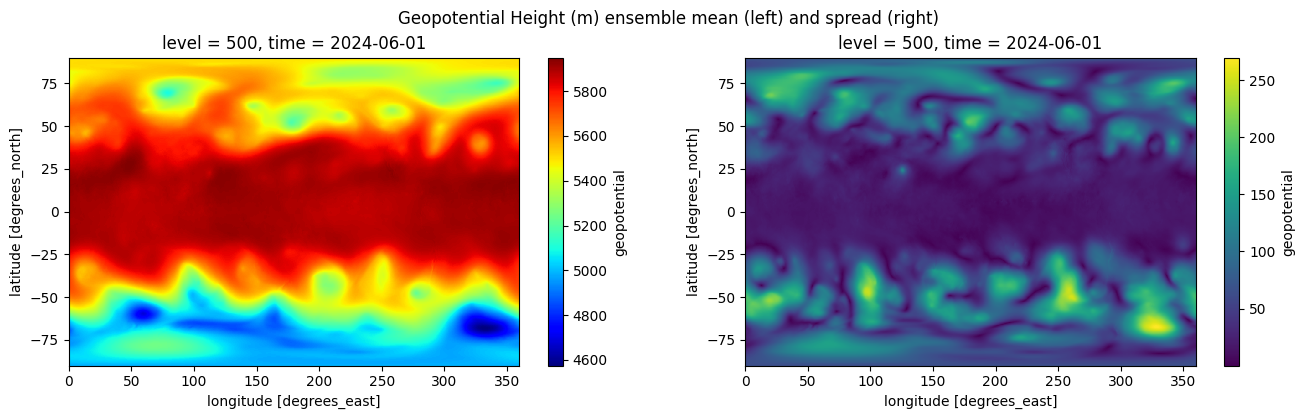

In [6]:
# Plot the ensemble mean and spread (standard deviation)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

plot_level = 500 # hPa

# Plot the ensemble mean geopotential height
gravitational_acceleration = 9.80665 
(ds['geopotential'].sel(level=plot_level).mean(dim='member')/gravitational_acceleration).plot(ax=ax1, cmap='jet') #'YlGnBu')#'Spectral') #'ocean') #

# Plot the ensemble spread of geopotential height
(ds['geopotential'].sel(level=plot_level).std(dim='member')/gravitational_acceleration).plot(ax=ax2, cmap='viridis')

plt.suptitle('Geopotential Height (m) ensemble mean (left) and spread (right)', y=0.999)
plt.show()